# Learned Speculative Training (LST)
## Extending Speculative Weight Prediction into Chaotic Training Regimes

This notebook implements and tests LST on **GPT-2 Medium (345M)** — a model large enough that backward passes are expensive and LST can demonstrate real wall-clock speedup.

**Make sure to select GPU runtime:** Runtime → Change runtime type → **A100 GPU**

## 1. Setup & Installation

In [1]:
!rm -rf LST

In [2]:
import os, sys, importlib

# Always fresh clone to avoid stale module cache issues
!rm -rf LST
!git clone https://github.com/RAVINDRA8008/Learned-Speculative-Training-LST-.git LST
%cd LST

# Remove any cached lst module so Python picks up the fresh code
if 'lst' in sys.modules:
    mods_to_remove = [k for k in sys.modules if k == 'lst' or k.startswith('lst.')]
    for m in mods_to_remove:
        del sys.modules[m]

!pip install -e . -q
!pip install wandb transformers torch tqdm matplotlib -q
!pip install datasets --upgrade -q

Cloning into 'LST'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 46 (delta 15), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 459.75 KiB | 5.68 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/LST
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 159.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 127.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 14.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 55.6 MB/s eta 0:00:00:00:

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import gc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB
Using device: cuda


## 2. Configuration

**GPT-2 Medium (345M)** with batch=16, seq=1024 + gradient checkpointing on A100. The 345M model has backward passes ~800ms+, making LST's ~200ms verification forward a massive win on accepted steps.

In [4]:
from dataclasses import dataclass

@dataclass
class Config:
    # Model — GPT-2 Medium (345M params)
    model_name: str = "gpt2-medium"
    n_embd: int = 1024
    n_layer: int = 24
    n_head: int = 16

    # Data
    dataset_name: str = "openwebtext"
    dataset_subset: str = None
    max_seq_len: int = 1024
    batch_size: int = 16       # 345M + checkpointing fits batch=16 on 40GB A100

    # Training
    total_steps: int = 2000
    lr: float = 3e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0
    gradient_checkpointing: bool = True

    # LST Specific
    lst_enabled: bool = True
    lst_warmup_steps: int = 200
    lst_K: int = 20
    lst_tolerance: float = 0.015
    lst_rank: int = 8
    lst_proj_dim: int = 32
    lst_grad_history: int = 4
    lst_draft_d_model: int = 256
    lst_draft_n_heads: int = 4
    lst_draft_n_blocks: int = 2
    lst_draft_lr: float = 3e-4
    lst_adaptive_tol: bool = True

    # AMP (mixed precision) — bfloat16 on A100
    use_amp: bool = True

    # Logging
    log_interval: int = 50
    eval_interval: int = 250
    use_wandb: bool = False
    seed: int = 42

config = Config()
print("Config ready!")
print(f"  Model: GPT-2 Medium (345M) — {config.n_layer}L, {config.n_embd}d, {config.n_head}H")
print(f"  LST enabled: {config.lst_enabled}")
print(f"  Total steps: {config.total_steps}")
print(f"  Batch size: {config.batch_size}, Seq len: {config.max_seq_len}")
print(f"  Gradient checkpointing: {config.gradient_checkpointing}")
print(f"  LST warmup: {config.lst_warmup_steps} steps")
print(f"  Supervision interval K={config.lst_K}")
print(f"  AMP (bfloat16): {config.use_amp}")

Config ready!
  Model: GPT-2 Medium (345M) — 24L, 1024d, 16H
  LST enabled: True
  Total steps: 2000
  Batch size: 16, Seq len: 1024
  Gradient checkpointing: True
  LST warmup: 200 steps
  Supervision interval K=20
  AMP (bfloat16): True


## 3. Data Loading

We use a streaming subset of OpenWebText (or wikitext as fallback for speed).

In [5]:
from transformers import AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader, IterableDataset

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

class StreamingTextDataset(IterableDataset):
    """Streams tokenized text chunks from a HuggingFace dataset."""

    def __init__(self, tokenizer, seq_len=256, split='train'):
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.split = split
        self.dataset = None
        self.text_key = 'text'

        # Try multiple loading strategies
        for name, config_name in [
            ('wikitext-103', 'wikitext-103-raw-v1'),
            ('wikitext-2', 'wikitext-2-raw-v1'),
        ]:
            try:
                self.dataset = load_dataset(
                    'wikitext', config_name,
                    split=split, trust_remote_code=True
                )
                print(f"Loaded {name} ({split}, {len(self.dataset)} examples)")
                break
            except Exception as e:
                print(f"{name} failed: {e}")

        # Ultimate fallback: use HF datasets with direct parquet URL
        if self.dataset is None:
            print("Trying direct parquet download...")
            try:
                import pandas as pd
                url = "https://huggingface.co/datasets/wikitext/resolve/main/wikitext-2-raw-v1/train-00000-of-00001.parquet"
                df = pd.read_parquet(url)
                self.dataset = df.to_dict('records')
                print(f"Loaded wikitext-2 via parquet ({len(self.dataset)} examples)")
            except Exception as e2:
                print(f"Parquet fallback failed: {e2}")
                print("Generating synthetic data for testing...")
                self.dataset = [{'text': f"The quick brown fox jumps over the lazy dog. Sentence number {i}. " * 10}
                               for i in range(10000)]

    def __iter__(self):
        buffer = []
        for example in self.dataset:
            text = example[self.text_key]
            if not text or len(text.strip()) < 10:
                continue
            tokens = self.tokenizer.encode(text)
            buffer.extend(tokens)

            while len(buffer) >= self.seq_len + 1:
                chunk = buffer[:self.seq_len + 1]
                buffer = buffer[self.seq_len:]
                input_ids = torch.tensor(chunk[:-1], dtype=torch.long)
                labels = torch.tensor(chunk[1:], dtype=torch.long)
                attention_mask = torch.ones_like(input_ids)
                yield {
                    'input_ids': input_ids,
                    'attention_mask': attention_mask,
                    'labels': labels,
                }

train_dataset = StreamingTextDataset(tokenizer, seq_len=config.max_seq_len, split='train')
train_loader = DataLoader(train_dataset, batch_size=config.batch_size)

# Quick test
test_batch = next(iter(train_loader))
print(f"Batch shapes: {test_batch['input_ids'].shape}")
print(f"Sample tokens: {tokenizer.decode(test_batch['input_ids'][0][:50])}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded wikitext-103 (train, 1801350 examples)
Batch shapes: torch.Size([16, 1024])
Sample tokens:  = Valkyria Chronicles III = 
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) ,


## 4. Model Setup

In [6]:
from transformers import GPT2LMHeadModel, GPT2Config

torch.manual_seed(config.seed)

# GPT-2 Medium (345M) — random init for clean training comparison
model_config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=config.max_seq_len,
    n_embd=config.n_embd,
    n_layer=config.n_layer,
    n_head=config.n_head,
    resid_pdrop=0.0,
    embd_pdrop=0.0,
    attn_pdrop=0.0,
)
model = GPT2LMHeadModel(model_config)
model = model.to(device)

# Gradient checkpointing: recomputes activations during backward
# Makes backward ~30-40% slower = more expensive = GOOD for LST
if config.gradient_checkpointing:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing ENABLED")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: GPT-2 Medium")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Layers: {config.n_layer}")
print(f"  Hidden dim: {config.n_embd}")
print(f"  Heads: {config.n_head}")

Gradient checkpointing ENABLED
Model: GPT-2 Medium
  Total parameters: 354,823,168
  Trainable parameters: 354,823,168
  Layers: 24
  Hidden dim: 1024
  Heads: 16


## 5. Optimizer & LR Schedule

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.lr,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999),
)

warmup_steps = int(config.total_steps * config.warmup_ratio)
warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=config.total_steps - warmup_steps, eta_min=config.lr * 0.1)
lr_scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

print(f"Optimizer: AdamW (lr={config.lr}, wd={config.weight_decay})")
print(f"LR Schedule: Linear warmup ({warmup_steps} steps) + Cosine decay")

Optimizer: AdamW (lr=0.0003, wd=0.01)
LR Schedule: Linear warmup (200 steps) + Cosine decay


## 6. Initialize LST Trainer

In [8]:
from lst.trainer import LSTTrainer

lst_trainer = LSTTrainer(
    model=model,
    optimizer=optimizer,
    K=config.lst_K,
    tolerance=config.lst_tolerance,
    warmup_steps=config.lst_warmup_steps,
    grad_history_len=config.lst_grad_history,
    proj_dim=config.lst_proj_dim,
    rank=config.lst_rank,
    total_steps=config.total_steps,
    draft_lr=config.lst_draft_lr,
    d_model=config.lst_draft_d_model,
    n_heads=config.lst_draft_n_heads,
    n_blocks=config.lst_draft_n_blocks,
    adaptive_tolerance=config.lst_adaptive_tol,
    max_grad_norm=config.max_grad_norm,
    use_amp=config.use_amp,
)

print(f"\nLST Trainer initialized!")
print(f"  Draft model: {lst_trainer.draft.count_parameters():,} params")
print(f"  Target layers for speculation: {len(lst_trainer.target_layers)}")
print(f"  Feature dim: {lst_trainer.feat_extractor.feat_dim}")
print(f"  Warmup: {config.lst_warmup_steps} steps")
print(f"  Supervision interval K={config.lst_K}")
print(f"  Tolerance: {config.lst_tolerance} (adaptive={config.lst_adaptive_tol})")
print(f"  AMP enabled: {config.use_amp}")

[LST] Target model has 96 2D parameter layers for speculative prediction
[LST] Total trainable params: 354,823,168
[LST] Draft model parameters: 5,179,136

LST Trainer initialized!
  Draft model: 5,179,136 params
  Target layers for speculation: 96
  Feature dim: 134
  Warmup: 200 steps
  Supervision interval K=20
  Tolerance: 0.015 (adaptive=True)
  AMP enabled: True


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 7. Training Loop

In [ ]:
# ============================================================
#  LST TRAINING LOOP
# ============================================================

# Tracking
losses = []
acceptance_rates = []
draft_losses = []
tolerances = []
accepted_flags = []
step_times = []
steps_done = 0

model.train()
pbar = tqdm(total=config.total_steps, desc="LST Training")

start_time = time.time()

for batch in train_loader:
    if steps_done >= config.total_steps:
        break

    step_start = time.time()

    # Current LR
    current_lr = optimizer.param_groups[0]['lr']

    # LST step
    result = lst_trainer.step_batch(batch, lr=current_lr)

    # LR scheduler step (only for non-speculative-accepted steps)
    if result.get('accepted') is not True:
        lr_scheduler.step()

    step_time = time.time() - step_start
    steps_done += 1

    # Record metrics
    losses.append(result['loss'])
    step_times.append(step_time)

    if result.get('accepted') is not None:
        accepted_flags.append(1 if result['accepted'] else 0)
    if result.get('acceptance_rate') is not None:
        acceptance_rates.append(result['acceptance_rate'])
    if result.get('draft_loss') is not None:
        draft_losses.append(result['draft_loss'])
    if result.get('tolerance') is not None:
        tolerances.append(result['tolerance'])

    # Logging
    if steps_done % config.log_interval == 0:
        avg_loss = np.mean(losses[-config.log_interval:])
        avg_time = np.mean(step_times[-config.log_interval:])
        phase = result.get('phase', 'unknown')

        log_msg = f"Step {steps_done}/{config.total_steps} | Loss: {avg_loss:.4f} | LR: {current_lr:.6f} | Phase: {phase} | {avg_time*1000:.1f}ms/step"

        if acceptance_rates:
            log_msg += f" | Accept: {acceptance_rates[-1]:.1%}"
        if result.get('tolerance') is not None:
            log_msg += f" | Tol: {result['tolerance']:.4f}"

        tqdm.write(log_msg)

    pbar.update(1)

pbar.close()
total_time = time.time() - start_time

# Save verifier stats before cleanup (lst_trainer will be deleted for baseline)
lst_total_accepted = lst_trainer.verifier.total_accepted
lst_total_speculative = lst_trainer.verifier.total_speculative
lst_final_tolerance = lst_trainer.verifier.tolerance
lst_draft_params = lst_trainer.draft.count_parameters()

print(f"\n{'='*60}")
print(f"Training complete!")
print(f"  Total steps:  {steps_done}")
print(f"  Total time:   {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"  Final loss:   {np.mean(losses[-50:]):.4f}")
print(f"  Avg ms/step:  {np.mean(step_times)*1000:.1f}")
if acceptance_rates:
    print(f"  Final acceptance rate: {acceptance_rates[-1]:.1%}")
    print(f"  Total accepted: {lst_total_accepted}")
    print(f"  Total speculative: {lst_total_speculative}")
print(f"{'='*60}")

LST Training:   0%|          | 0/2000 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step 50/2000 | Loss: 8.7311 | LR: 0.000076 | Phase: warmup | 1159.8ms/step
Step 100/2000 | Loss: 7.3826 | LR: 0.000150 | Phase: warmup | 939.7ms/step
Step 150/2000 | Loss: 7.2911 | LR: 0.000224 | Phase: warmup | 941.5ms/step
Step 200/2000 | Loss: 7.2022 | LR: 0.000299 | Phase: warmup | 940.9ms/step


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step 250/2000 | Loss: 7.1687 | LR: 0.000300 | Phase: speculative | 655.2ms/step | Accept: 58.3% | Tol: 0.0150
Step 300/2000 | Loss: 7.1237 | LR: 0.000300 | Phase: forced_supervision | 499.8ms/step | Accept: 67.4%
Step 350/2000 | Loss: 7.1254 | LR: 0.000300 | Phase: speculative | 485.5ms/step | Accept: 70.6% | Tol: 0.0150
Step 400/2000 | Loss: 7.0881 | LR: 0.000299 | Phase: forced_supervision | 480.3ms/step | Accept: 72.6%
Step 450/2000 | Loss: 7.0675 | LR: 0.000299 | Phase: speculative | 391.3ms/step | Accept: 75.6% | Tol: 0.0095
Step 500/2000 | Loss: 7.0586 | LR: 0.000299 | Phase: forced_supervision | 518.3ms/step | Accept: 75.4%
Step 550/2000 | Loss: 7.0523 | LR: 0.000298 | Phase: speculative | 542.1ms/step | Accept: 74.8% | Tol: 0.0095


## 8. Baseline Comparison (Standard Training)

In [ ]:
# ============================================================
#  BASELINE: Standard training (no LST) for comparison
# ============================================================

# Free LST model and draft to reclaim GPU memory
del model, lst_trainer
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.1f} GB")

# Re-initialize model with same seed
torch.manual_seed(config.seed)
baseline_model = GPT2LMHeadModel(model_config).to(device)

# Same gradient checkpointing for fair comparison
if config.gradient_checkpointing:
    baseline_model.gradient_checkpointing_enable()

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=config.lr,
    weight_decay=config.weight_decay, betas=(0.9, 0.999),
)
baseline_warmup = LinearLR(baseline_optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
baseline_cosine = CosineAnnealingLR(baseline_optimizer, T_max=config.total_steps - warmup_steps, eta_min=config.lr * 0.1)
baseline_lr_sched = SequentialLR(baseline_optimizer, schedulers=[baseline_warmup, baseline_cosine], milestones=[warmup_steps])

# Reload data
baseline_dataset = StreamingTextDataset(tokenizer, seq_len=config.max_seq_len, split='train')
baseline_loader = DataLoader(baseline_dataset, batch_size=config.batch_size)

baseline_losses = []
baseline_times = []
baseline_steps = 0

baseline_model.train()
pbar = tqdm(total=config.total_steps, desc="Baseline Training")
baseline_start = time.time()

for batch in baseline_loader:
    if baseline_steps >= config.total_steps:
        break

    step_start = time.time()

    batch = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
    baseline_optimizer.zero_grad()
    with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=config.use_amp):
        output = baseline_model(**batch)
        loss = output.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), config.max_grad_norm)
    baseline_optimizer.step()
    baseline_lr_sched.step()

    step_time = time.time() - step_start
    baseline_steps += 1
    baseline_losses.append(loss.item())
    baseline_times.append(step_time)

    if baseline_steps % config.log_interval == 0:
        avg_loss = np.mean(baseline_losses[-config.log_interval:])
        avg_time = np.mean(baseline_times[-config.log_interval:])
        tqdm.write(f"Baseline Step {baseline_steps}/{config.total_steps} | Loss: {avg_loss:.4f} | {avg_time*1000:.1f}ms/step")

    pbar.update(1)

pbar.close()
baseline_total_time = time.time() - baseline_start

print(f"\nBaseline complete!")
print(f"  Total time: {baseline_total_time:.1f}s ({baseline_total_time/60:.1f} min)")
print(f"  Final loss: {np.mean(baseline_losses[-50:]):.4f}")
print(f"  Avg ms/step: {np.mean(baseline_times)*1000:.1f}")

GPU memory after cleanup: 2.0 GB


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded wikitext-103 (train, 1801350 examples)


Baseline Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Baseline Step 50/2000 | Loss: 9.1685 | 341.0ms/step
Baseline Step 100/2000 | Loss: 7.4559 | 338.7ms/step
Baseline Step 150/2000 | Loss: 7.1996 | 338.7ms/step
Baseline Step 200/2000 | Loss: 7.0980 | 338.7ms/step
Baseline Step 250/2000 | Loss: 6.9754 | 338.8ms/step
Baseline Step 300/2000 | Loss: 6.8928 | 338.8ms/step
Baseline Step 350/2000 | Loss: 6.8377 | 338.7ms/step
Baseline Step 400/2000 | Loss: 6.7836 | 338.8ms/step
Baseline Step 450/2000 | Loss: 6.7282 | 338.7ms/step


KeyboardInterrupt: 

## 9. Results & Visualization

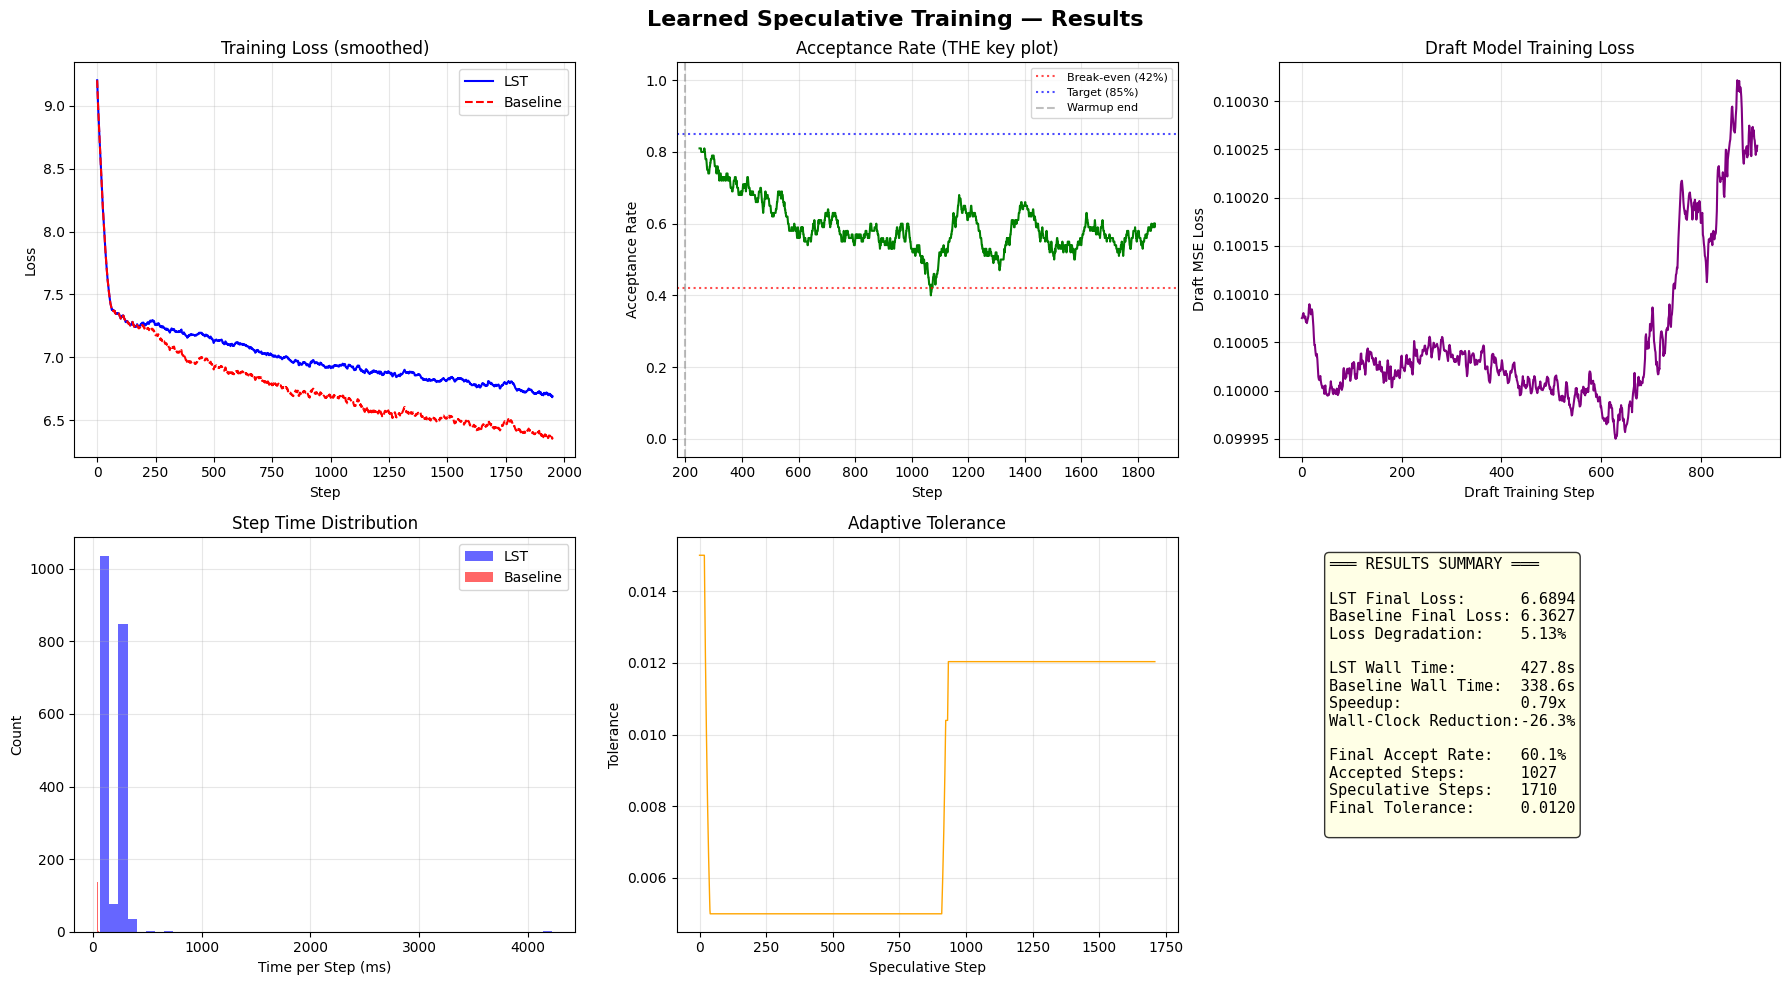

Results saved to lst_results.png


In [ ]:
# ============================================================
#  PLOTS: Loss curves, acceptance rate, speedup analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learned Speculative Training — GPT-2 Medium (345M)', fontsize=16, fontweight='bold')

# --- Plot 1: Training Loss Comparison ---
ax = axes[0, 0]
window = 50
if len(losses) > window:
    smoothed_lst = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(smoothed_lst, label='LST', color='blue', linewidth=1.5)
if len(baseline_losses) > window:
    smoothed_base = np.convolve(baseline_losses, np.ones(window)/window, mode='valid')
    ax.plot(smoothed_base, label='Baseline', color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Acceptance Rate Over Training ---
ax = axes[0, 1]
if accepted_flags:
    rolling_window = 100
    if len(accepted_flags) > rolling_window:
        rolling_accept = np.convolve(
            accepted_flags, np.ones(rolling_window)/rolling_window, mode='valid'
        )
        x_offset = config.lst_warmup_steps + rolling_window // 2
        ax.plot(range(x_offset, x_offset + len(rolling_accept)), rolling_accept,
                color='green', linewidth=1.5)
    ax.axhline(y=0.42, color='red', linestyle=':', alpha=0.7, label='Break-even (42%)')
    ax.axhline(y=0.85, color='blue', linestyle=':', alpha=0.7, label='Target (85%)')
    ax.axvline(x=config.lst_warmup_steps, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
ax.set_xlabel('Step')
ax.set_ylabel('Acceptance Rate')
ax.set_title('Acceptance Rate (THE key plot)')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 3: Draft Model Loss ---
ax = axes[0, 2]
if draft_losses:
    dl_window = min(50, len(draft_losses))
    if len(draft_losses) > dl_window:
        smoothed_dl = np.convolve(draft_losses, np.ones(dl_window)/dl_window, mode='valid')
        ax.plot(smoothed_dl, color='purple', linewidth=1.5)
    else:
        ax.plot(draft_losses, color='purple', linewidth=1.5)
ax.set_xlabel('Draft Training Step')
ax.set_ylabel('Draft MSE Loss')
ax.set_title('Draft Model Training Loss')
ax.grid(True, alpha=0.3)

# --- Plot 4: Step Time Comparison ---
ax = axes[1, 0]
bins = 50
if step_times:
    ax.hist(np.array(step_times)*1000, bins=bins, alpha=0.6, color='blue', label='LST')
if baseline_times:
    ax.hist(np.array(baseline_times)*1000, bins=bins, alpha=0.6, color='red', label='Baseline')
ax.set_xlabel('Time per Step (ms)')
ax.set_ylabel('Count')
ax.set_title('Step Time Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 5: Tolerance Adaptation ---
ax = axes[1, 1]
if tolerances:
    ax.plot(tolerances, color='orange', linewidth=1.0)
ax.set_xlabel('Speculative Step')
ax.set_ylabel('Tolerance')
ax.set_title('Adaptive Tolerance')
ax.grid(True, alpha=0.3)

# --- Plot 6: Summary Stats ---
ax = axes[1, 2]
ax.axis('off')
speedup = baseline_total_time / total_time
wall_reduction = (1 - total_time / baseline_total_time) * 100
loss_deg = ((np.mean(losses[-50:]) - np.mean(baseline_losses[-50:])) / np.mean(baseline_losses[-50:])) * 100

summary_text = (
    f"═══ RESULTS SUMMARY ═══\n\n"
    f"Model: GPT-2 Medium (345M)\n"
    f"LST Final Loss:      {np.mean(losses[-50:]):.4f}\n"
    f"Baseline Final Loss: {np.mean(baseline_losses[-50:]):.4f}\n"
    f"Loss Degradation:    {loss_deg:.2f}%\n\n"
    f"LST Wall Time:       {total_time:.1f}s\n"
    f"Baseline Wall Time:  {baseline_total_time:.1f}s\n"
    f"Speedup:             {speedup:.2f}x\n"
    f"Wall-Clock Reduction:{wall_reduction:.1f}%\n\n"
)
if acceptance_rates:
    summary_text += (
        f"Final Accept Rate:   {acceptance_rates[-1]:.1%}\n"
        f"Accepted Steps:      {lst_total_accepted}\n"
        f"Speculative Steps:   {lst_total_speculative}\n"
        f"Final Tolerance:     {lst_final_tolerance:.4f}\n"
    )
ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('lst_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved to lst_results.png")

## 10. Detailed Analysis

In [ ]:
# ============================================================
#  ANALYSIS: Training regime breakdown
# ============================================================

print("\n" + "="*60)
print("TRAINING REGIME ANALYSIS")
print("="*60)

if accepted_flags:
    flags = np.array(accepted_flags)

    # Split into training phases
    # Chaotic: first 1/3 of speculative steps
    # Transition: middle 1/3
    # Stable: final 1/3
    n = len(flags)
    third = n // 3

    chaotic_rate = flags[:third].mean() if third > 0 else 0
    transition_rate = flags[third:2*third].mean() if third > 0 else 0
    stable_rate = flags[2*third:].mean() if third > 0 else 0

    print(f"\nAcceptance Rate by Training Phase:")
    print(f"  Chaotic (early):     {chaotic_rate:.1%}  (Leap+Verify target: ~9%)")
    print(f"  Transition (middle): {transition_rate:.1%}  (Leap+Verify target: ~20-30%)")
    print(f"  Stable (late):       {stable_rate:.1%}  (Leap+Verify target: ~37%)")
    print(f"  Overall:             {flags.mean():.1%}")

    # Cost analysis
    p = flags.mean()
    K = config.lst_K
    cost_per_step = p * 1.075 + (1-p) * 4.125 + (1/K) * 3.0
    baseline_cost = 3.0
    theoretical_speedup = baseline_cost / cost_per_step

    print(f"\nTheoretical Cost Analysis (from paper's model):")
    print(f"  Acceptance rate p = {p:.3f}")
    print(f"  Cost per step: {cost_per_step:.3f} (baseline: {baseline_cost:.3f})")
    print(f"  Theoretical speedup: {theoretical_speedup:.2f}x")
    print(f"  Theoretical wall-clock reduction: {(1 - 1/theoretical_speedup)*100:.1f}%")

    print(f"\nActual Measured:")
    print(f"  LST total time:      {total_time:.1f}s")
    print(f"  Baseline total time:  {baseline_total_time:.1f}s")
    print(f"  Measured speedup:     {baseline_total_time/total_time:.2f}x")
    print(f"  Measured reduction:   {(1 - total_time/baseline_total_time)*100:.1f}%")
else:
    print("No speculative steps recorded (still in warmup?)")

# Draft model analysis
if draft_losses:
    print(f"\nDraft Model Analysis:")
    print(f"  Initial draft loss: {draft_losses[0]:.6f}")
    print(f"  Final draft loss:   {draft_losses[-1]:.6f}")
    if draft_losses[0] > 0:
        print(f"  Improvement:        {(1 - draft_losses[-1]/draft_losses[0])*100:.1f}%")

print("\n" + "="*60)


TRAINING REGIME ANALYSIS

Acceptance Rate by Training Phase:
  Chaotic (early):     67.7%  (Leap+Verify target: ~9%)
  Transition (middle): 54.6%  (Leap+Verify target: ~20-30%)
  Stable (late):       57.9%  (Leap+Verify target: ~37%)
  Overall:             60.1%

Theoretical Cost Analysis (from paper's model):
  Acceptance rate p = 0.601
  Cost per step: 2.443 (baseline: 3.000)
  Theoretical speedup: 1.23x
  Theoretical wall-clock reduction: 18.6%

Actual Measured:
  LST total time:      427.8s
  Baseline total time:  338.6s
  Measured speedup:     0.79x
  Measured reduction:   -26.3%

Draft Model Analysis:
  Initial draft loss: 0.099996
  Final draft loss:   0.100548
  Improvement:        -0.6%



## 11. Save Results

In [ ]:
import json

results = {
    'config': {
        'model': 'gpt2_medium_345m',
        'n_embd': config.n_embd,
        'n_layer': config.n_layer,
        'n_head': config.n_head,
        'batch_size': config.batch_size,
        'max_seq_len': config.max_seq_len,
        'total_steps': config.total_steps,
        'lst_warmup': config.lst_warmup_steps,
        'lst_K': config.lst_K,
        'lst_rank': config.lst_rank,
        'lr': config.lr,
        'gradient_checkpointing': config.gradient_checkpointing,
    },
    'lst': {
        'final_loss': float(np.mean(losses[-50:])),
        'total_time_s': total_time,
        'avg_ms_per_step': float(np.mean(step_times) * 1000),
        'acceptance_rate': float(acceptance_rates[-1]) if acceptance_rates else 0,
        'total_accepted': lst_total_accepted,
        'total_speculative': lst_total_speculative,
        'draft_params': lst_draft_params,
    },
    'baseline': {
        'final_loss': float(np.mean(baseline_losses[-50:])),
        'total_time_s': baseline_total_time,
        'avg_ms_per_step': float(np.mean(baseline_times) * 1000),
    },
    'comparison': {
        'speedup': baseline_total_time / total_time,
        'wall_clock_reduction_pct': (1 - total_time / baseline_total_time) * 100,
        'loss_degradation_pct': ((np.mean(losses[-50:]) - np.mean(baseline_losses[-50:])) / np.mean(baseline_losses[-50:])) * 100,
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to results.json")
print(json.dumps(results, indent=2))

Results saved to results.json
{
  "config": {
    "model": "gpt2_124m",
    "total_steps": 2000,
    "lst_warmup": 200,
    "lst_K": 20,
    "lst_rank": 8,
    "lr": 0.0003
  },
  "lst": {
    "final_loss": 6.689388780593872,
    "total_time_s": 427.75926899909973,
    "acceptance_rate": 0.6005847953216374,
    "total_accepted": 1027,
    "total_speculative": 1710
  },
  "baseline": {
    "final_loss": 6.362742786407471,
    "total_time_s": 338.587025642395
  },
  "comparison": {
    "speedup": 0.7915363854876692,
    "wall_clock_reduction_pct": -26.336580141403765,
    "loss_degradation_pct": 5.133729354645695
  }
}
